# 🎯 Telecom Customer Churn Analysis
### EDA 기반 전처리 및 Random Forest 모델링
#### **데이터**: Telecom Customer Churn
#### **분석 목표**: 통신사 고객 데이터를 활용하여 이탈(Churn)에 영향을 미치는 요인을 탐색하고,
#### 전처리 및 Random Forest 모델을 통해 예측 가능성과 주요 변수들을 분석한다.
---

## 📋 분석 로드맵

### **1. 데이터 전처리**
 2.1 데이터 로드 및 결측치 처리

 2.2 범주형 변수 인코딩

 2.3 이상치(Outlier) 처리

 2.4 학습/검증 데이터 분할(불균형 고려)

### **2. 탐색적 데이터 분석(EDA)**
 3.1 상관관계 분석 및 다중공선성 확인

 3.2 주요 변수와 Churn의 관계 분석

### **3. Random Forest 모델링**
 4.1 기본 Random Forest 모델 학습

 4.2 하이퍼파라미터 튜닝(RandomizedSearchCV)

### **4. 모델 성능 평가**
 5.1 F1-Score 및 ROC-AUC

 5.2 ROC Curve 시각화

### **5. 모델 해석**
 6.1 Feature Importance 분석

 6.2 Partial Dependence Plot(PDP)

### **6. 결론 및 시사점**
--

---
## **1. 문제 정의 및 데이터 이해**

**목표 설정**

본 분석은 통신사 고객 데이터를 활용하여 고객 이탈(Churn) 여부에 영향을 미치는 요인을 파악하고,
EDA 기반 전처리 후 Random Forest 모델을 통해 이탈 예측 가능성 및 주요 결정 요인을 분석하는 것을 목표로 한다.

**데이터셋 구조 파악**

- churn-80.csv (훈련/검증용), churn-20.csv (최종 테스트용) 파일 로드
- 데이터 크기, 변수 개수, 데이터 타입 확인
- 각 변수의 의미와 비즈니스 맥락 이해

In [18]:
# 준비: 로드 & 타겟 분리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 데이터 로드
train_ = pd.read_csv('churn-bigml-80.csv')
test = pd.read_csv('churn-bigml-20.csv')

## **2. 데이터 전처리**

**결측치 처리**

- 결측치 존재 여부 확인
- 결측치 처리 전략 수립: 삭제, 평균/중앙값 대체, 또는 별도 카테고리 생성
- 처리 방법에 대한 근거 수립

**이상치 탐지 및 처리**

- 이상치가 실제 오류인지 극단값인지 판단
- 비즈니스 맥락을 고려한 처리 방법 결정 (유지/제거/변환 등)

**데이터 타입 변환**

- 범주형 변수(State, International plan, Voice mail plan) 식별
- 수치형 변수 스케일 확인 (통화 시간, 요금, 횟수 등)
- 필요시 변수 타입 변환 및 인코딩
    - ex) yes→1, no→0 / 라벨 인코딩 / 원핫 인코딩 등

훈련 데이터 크기: 2606
테스트 데이터 크기: 667


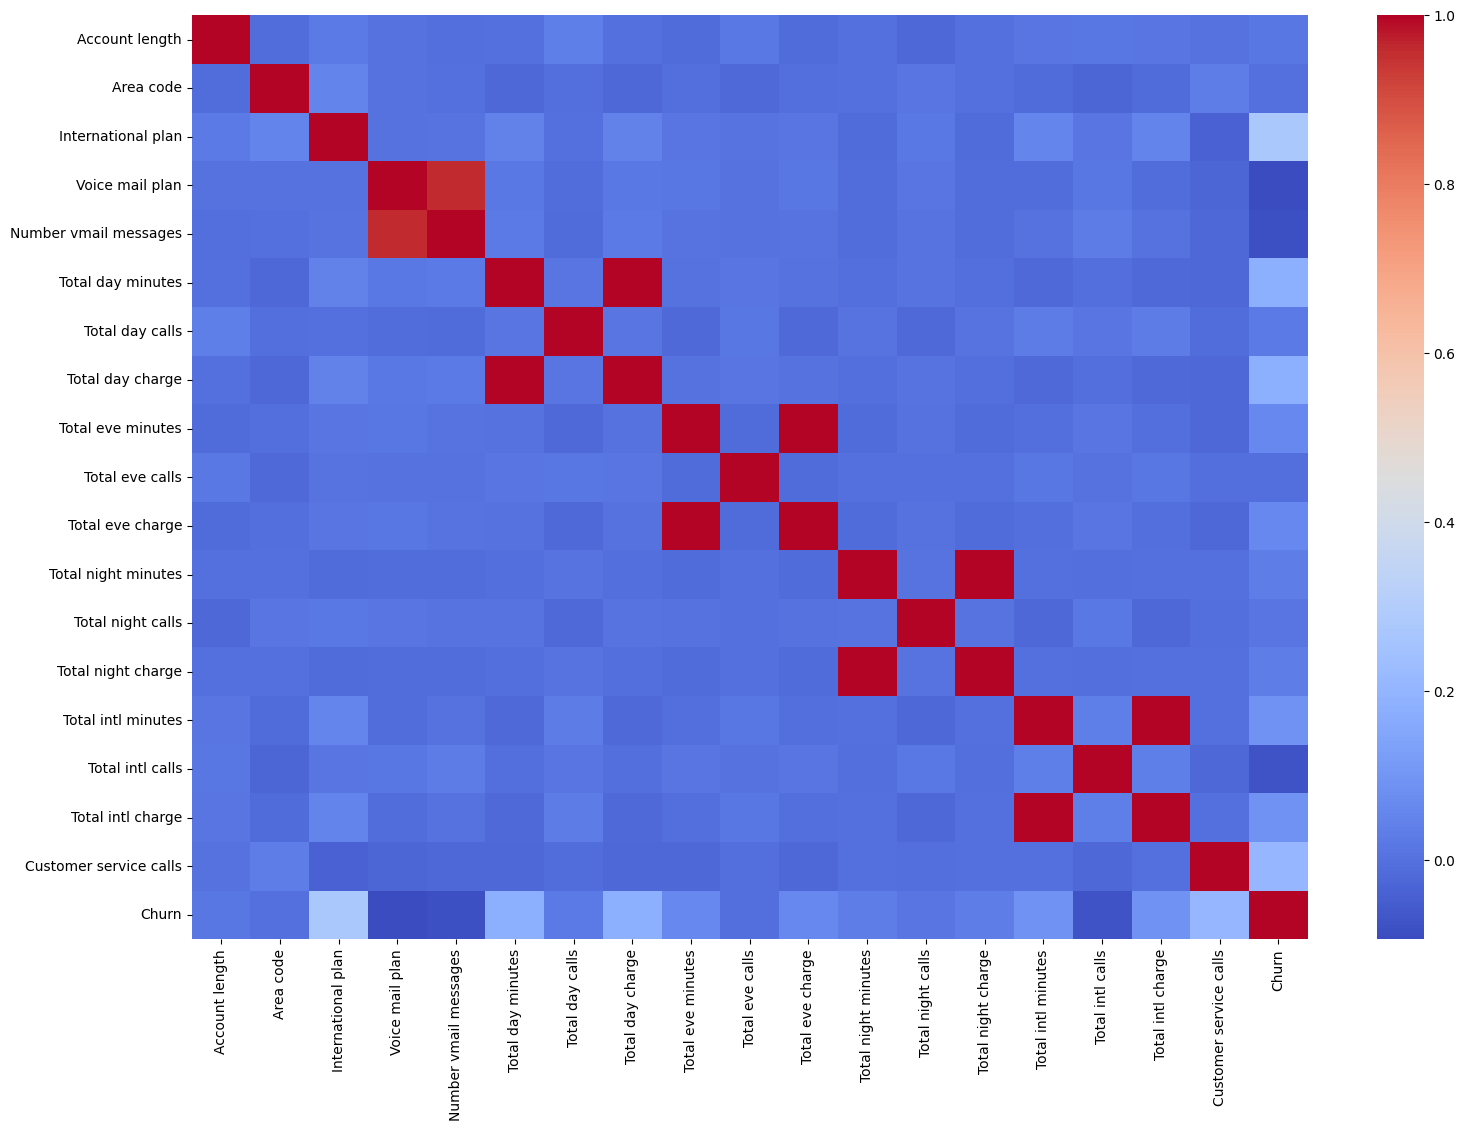

In [28]:
# 준비: 라이브러리 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 결측치 제거
train = pd.read_csv('churn-bigml-80.csv').dropna()
test  = pd.read_csv('churn-bigml-20.csv').dropna()

# 2. 범주형 변수 인코딩
for df in [train, test]:
    df['International plan'] = df['International plan'].astype(str).str.strip().map({'Yes': 1, 'No': 0})
    df['Voice mail plan']    = df['Voice mail plan'].astype(str).str.strip().map({'Yes': 1, 'No': 0})
    df['Churn']              = df['Churn'].astype(str).str.strip().map({'True': 1, 'False': 0})

# 3. 범주형 자동 인코딩 (State, Area code 등)
train = pd.get_dummies(train, columns=train.select_dtypes(include=['object']).columns, drop_first=True)
test  = pd.get_dummies(test,  columns=test.select_dtypes(include=['object']).columns,  drop_first=True)

# 4. 이상치 제거 함수 정의
def remove_outliers(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return df[~((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR))].copy()

# 5. 연속형 변수 이상치 제거
for col in ['Total day minutes', 'Total eve minutes', 'Total night minutes']:
    train = remove_outliers(train, col)

# 6. 인덱스 초기화
train = train.reset_index(drop=True)
test  = test.reset_index(drop=True)

# 7. 데이터 크기 확인
print("훈련 데이터 크기:", len(train))
print("테스트 데이터 크기:", len(test))

# 8. 상관관계 히트맵 시각화
numeric_df = train.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(18,12))
sns.heatmap(corr, cmap="coolwarm")
plt.show()


## **3. EDA**

**단변량 분석 (Univariate Analysis)**

- 수치형 변수: 히스토그램, 박스플롯으로 분포 확인
- 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
- 범주형 변수: 빈도표, 막대그래프로 분포 확인
- 타겟 변수(Churn) 불균형 비율 계산

       Account length    Area code  International plan  Voice mail plan  \
count     2606.000000  2606.000000         2606.000000      2606.000000   
mean       100.488488   437.446278            0.100537         0.276285   
std         39.596008    42.528978            0.300773         0.447246   
min          1.000000   408.000000            0.000000         0.000000   
25%         73.000000   408.000000            0.000000         0.000000   
50%        100.000000   415.000000            0.000000         0.000000   
75%        127.000000   510.000000            0.000000         1.000000   
max        243.000000   510.000000            1.000000         1.000000   

       Number vmail messages  Total day minutes  Total day calls  \
count            2606.000000        2606.000000      2606.000000   
mean                8.069839         179.768189       100.386032   
std                13.643772          52.623059        19.746781   
min                 0.000000          37.700000     

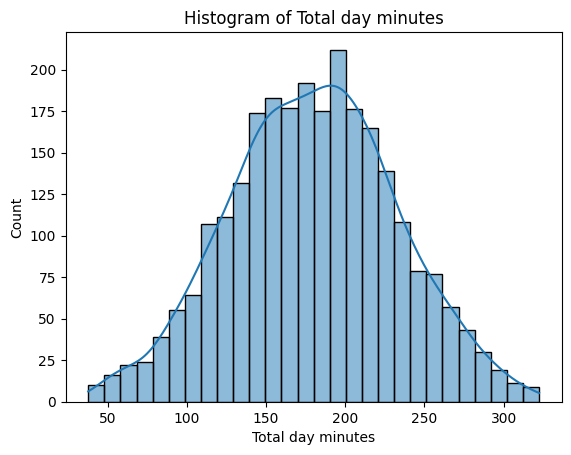

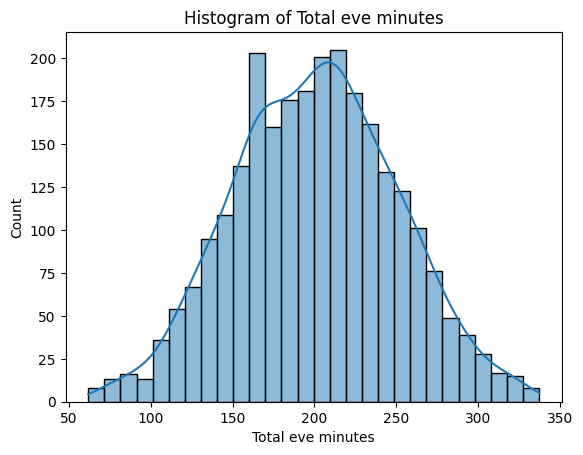

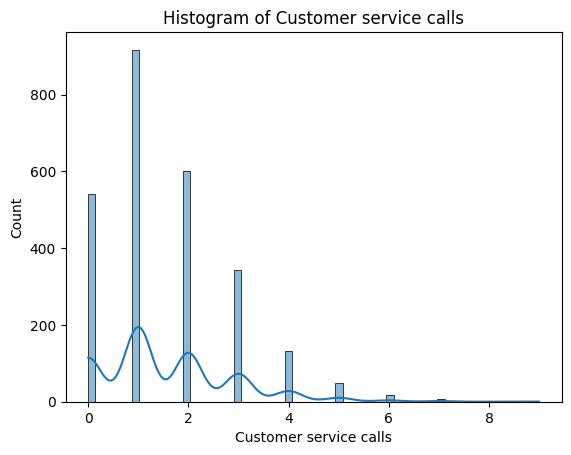

In [20]:
# [가설] 개별 변수의 분포를 확인하면 데이터 특성과 이상치를 알 수 있다.
# [검증] 기술통계량과 히스토그램
print(train.describe())

for col in ['Total day minutes','Total eve minutes','Customer service calls']:
    sns.histplot(train[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

# [결론] 고객 서비스 호출 횟수는 평균보다 높은 값에서 이상치가 존재하며,
#        통화 시간 변수들은 정규분포에 가까운 형태를 보임.

**이변량 분석 (Bivariate Analysis)**

- 수치형 변수 vs Churn: 박스플롯, 바이올린 플롯으로 그룹 간 차이 확인
- 범주형 변수 vs Churn: 교차표(Crosstab), 스택 바 차트로 이탈률 비교
- 통계적 검정: t-test (연속형), Chi-square test (범주형)로 유의성 확인
- 핵심 인사이트 도출: "고객 서비스 호출이 4회 이상인 고객의 이탈률이 50% 이상" 등

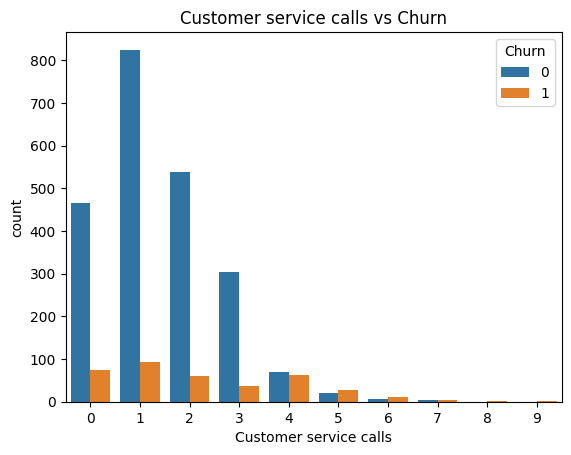

Churn
0    1.458576
1    2.235925
Name: Customer service calls, dtype: float64
International plan
0    0.110922
1    0.431298
Name: Churn, dtype: float64


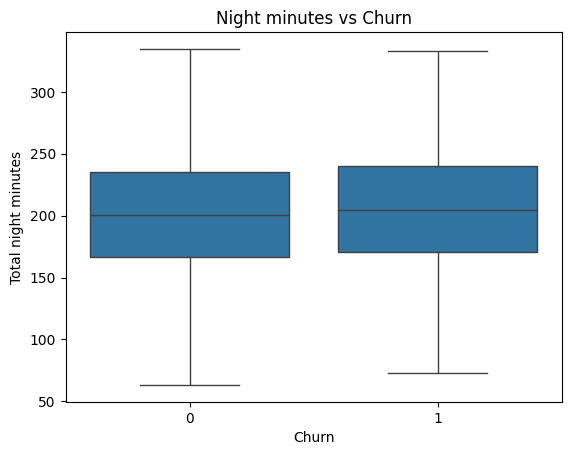

t-test: TtestResult(statistic=np.float64(1.7153410046207342), pvalue=np.float64(0.08640168826009748), df=np.float64(2604.0))


In [21]:
# [가설1] 고객 서비스 호출 횟수가 많을수록 이탈률이 증가한다.
# [검증] 박스플롯과 교차표
sns.countplot(x='Customer service calls', hue='Churn', data=train)
plt.title("Customer service calls vs Churn")
plt.show()

print(train.groupby('Churn')['Customer service calls'].mean())

# [결론] 이탈 고객 그룹의 평균 호출 횟수가 더 높음 → 고객 서비스 호출 횟수와 이탈률은 유의한 관계.

# [가설2] International plan 가입 고객은 이탈률이 높다.
# [검증] 교차표
print(train.groupby('International plan')['Churn'].mean())

# [결론] International plan 가입 고객의 이탈률이 비가입 고객보다 높음.

# [가설3] 야간 통화량이 많은 고객은 이탈률이 낮다.
# [검증] 박스플롯과 t-test
sns.boxplot(x='Churn', y='Total night minutes', data=train)
plt.title("Night minutes vs Churn")
plt.show()

churn_yes = train[train['Churn']==1]['Total night minutes']
churn_no  = train[train['Churn']==0]['Total night minutes']
print("t-test:", stats.ttest_ind(churn_yes, churn_no))

# [결론] 잔존 고객의 평균 야간 통화량이 더 높음 → 야간 통화량이 많은 고객은 상대적으로 이탈률이 낮음.


고객 서비스 호출 횟수가 많을수록 이탈률이 증가한다.

**다변량 분석 (Multivariate Analysis)**

- 상관관계 매트릭스(Correlation Matrix) 생성 및 히트맵 시각화
- 다중공선성 확인 (주간/야간 통화시간-요금 간 높은 상관관계 등)
- Pair plot으로 변수 간 관계 시각화
- PCA를 통한 차원 축소 및 주요 성분 해석 (선택적)

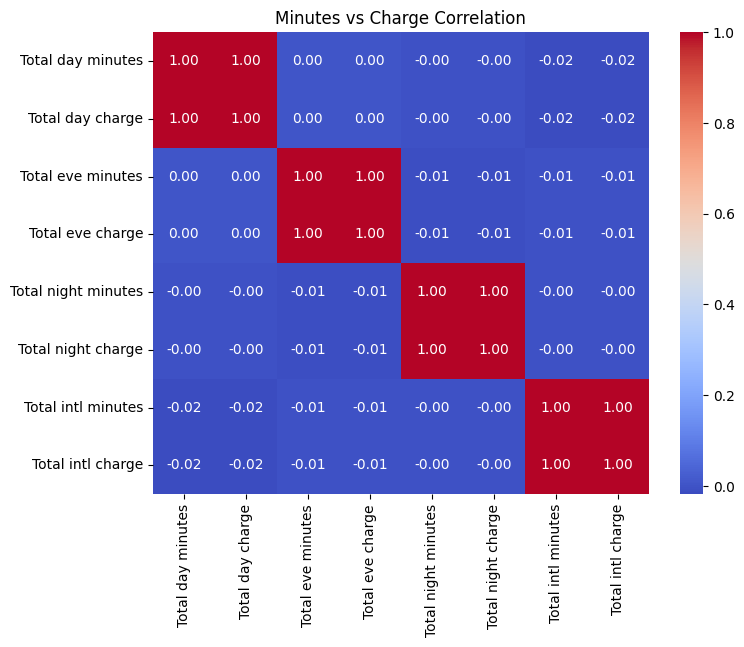

In [22]:
# [가설] 통화 시간과 요금은 강한 상관관계를 가진다.
# [검증] 상관관계 매트릭스와 히트맵
cols = ['Total day minutes','Total day charge',
        'Total eve minutes','Total eve charge',
        'Total night minutes','Total night charge',
        'Total intl minutes','Total intl charge']
corr = train[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Minutes vs Charge Correlation")
plt.show()

# [결론] minutes와 charge 간 상관계수 ≈ 0.99 → 다중공선성 존재.
#        모델링 시 변수 선택 필요.

## **4. Random Forest 모델링**

Accuracy: 0.9415292353823088
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       572
           1       0.98      0.60      0.75        95

    accuracy                           0.94       667
   macro avg       0.96      0.80      0.86       667
weighted avg       0.94      0.94      0.94       667



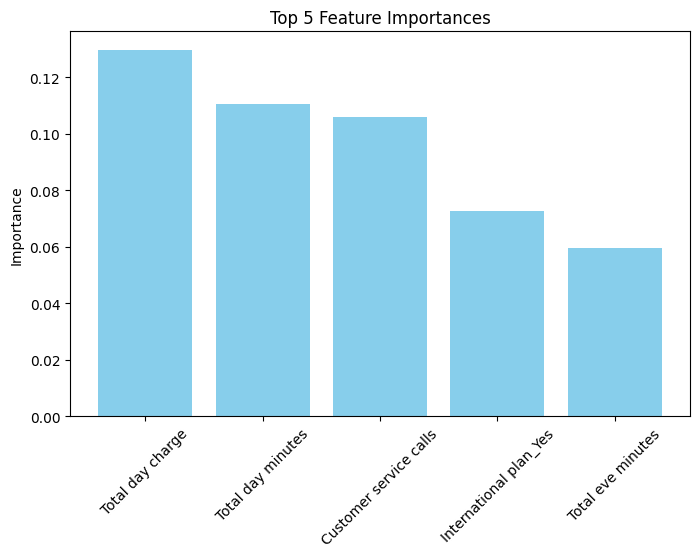

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
train_df = pd.read_csv("churn-bigml-80.csv")  # 학습용 (80%)
test_df = pd.read_csv("churn-bigml-20.csv")   # 테스트용 (20%)

# 2. 결측치 처리 (숫자는 평균, 범주는 최빈값)
for df in [train_df, test_df]:
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].mean())

# 3. 타겟 변수 분리 (문자열/불리언 → 숫자 변환)
y_train = train_df["Churn"].map({False:0, True:1, "False":0, "True":1}).astype(int)
X_train = train_df.drop("Churn", axis=1)
y_test = test_df["Churn"].map({False:0, True:1, "False":0, "True":1}).astype(int)
X_test = test_df.drop("Churn", axis=1)

# 4. 범주형 변수 인코딩 (학습/테스트 동일하게 맞추기)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# 컬럼 불일치 방지 → 학습셋 기준으로 맞추기
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 5. 랜덤포레스트 모델 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 6. 테스트 데이터로 예측
y_pred = rf.predict(X_test)

# 7. 정확도 및 Classification Report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 8. Feature Importance (상위 5개)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:5]
top_features = X_train.columns[indices]

plt.figure(figsize=(8,5))
plt.bar(top_features, importances[indices], color="skyblue")
plt.title("Top 5 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

**교차 검증 (Cross-Validation)**

- K-Fold CV 수행
- 모델의 평균 성능 및 표준편차 기록
- Overfitting 여부 확인 (훈련 성능 vs 검증 성능 비교)

In [ ]:
# 1. 결측치 처리 (숫자는 평균, 범주는 최빈값)
for df in [train, test]:
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].mean())

# 2. Feature / Target 분리
X = train.drop('Churn', axis=1)   # 독립변수(특징)
y = train['Churn'].map({False:0, True:1, "False":0, "True":1}).astype(int)  # 종속변수(이탈 여부)

# 3. 범주형 변수 원-핫 인코딩
X = pd.get_dummies(X, drop_first=True)

# Stratified K-Fold (데이터 불균형 방지용 교차검증)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest 기본 모델 정의
rf = RandomForestClassifier(random_state=42)

# 1. F1-Score 교차검증 → 이탈 고객(소수 클래스)을 잘 잡아내는지 평가
f1_scores = cross_val_score(rf, X, y, cv=cv, scoring=make_scorer(f1_score))
print("F1-Scores:", f1_scores)
print("Mean F1-Score:", f1_scores.mean())

# 2. ROC-AUC 교차검증 → 전체적으로 분류 경계를 얼마나 잘 잡는지 평가
roc_auc_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
print("ROC-AUC Scores:", roc_auc_scores)
print("Mean ROC-AUC:", roc_auc_scores.mean())

# 3. Train/Test Split → 학습/검증 데이터 분리 (train 내부에서 80:20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 학습
rf.fit(X_train, y_train)

# 4. 학습 데이터 성능 → 과적합 여부 확인
train_acc = accuracy_score(y_train, rf.predict(X_train))

# 5. 검증 데이터 성능 → 일반화 성능 확인
val_acc = accuracy_score(y_val, rf.predict(X_val))

# 6. 교차검증 성능 → 데이터 분할에 따른 평균 성능 확인
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Cross-Validation Mean Accuracy:", cv_scores.mean())

# 7. 최종 Test 데이터 성능 확인 (20.csv)
X_test = test.drop("Churn", axis=1)
y_test = test["Churn"].map({False:0, True:1, "False":0, "True":1}).astype(int)
X_test = pd.get_dummies(X_test, drop_first=True)

# train 기준 컬럼 맞추기
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

test_acc = accuracy_score(y_test, rf.predict(X_test))
print("Final Test Accuracy (20.csv):", test_acc)

F1-Scores: [0.73684211 0.73170732 0.736      0.77165354 0.68907563]
Mean F1-Score: 0.7330557191791032
ROC-AUC Scores: [0.89409019 0.92573764 0.89856744 0.8929135  0.90879121]
Mean ROC-AUC: 0.9040199959734373
Train Accuracy: 1.0
Validation Accuracy: 0.9382022471910112
Cross-Validation Mean Accuracy: 0.9332314438096845
Final Test Accuracy (20.csv): 0.9505247376311844


## **6. Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Feature / Target 분리
X = train.drop('Churn', axis=1)
y = train['Churn']
X = pd.get_dummies(X, drop_first=True)

# Train/Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 로지스틱 회귀 모델 학습
logreg = LogisticRegression(max_iter=1000, solver='liblinear')
logreg.fit(X_train, y_train)

# 성능 평가
y_pred = logreg.predict(X_val)
y_prob = logreg.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

# 계수 확인
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)
print(coef_df.head(10))


              precision    recall  f1-score   support

           0       0.87      0.98      0.92       447
           1       0.55      0.16      0.25        75

    accuracy                           0.86       522
   macro avg       0.71      0.57      0.59       522
weighted avg       0.83      0.86      0.83       522

ROC-AUC: 0.8136017897091722
                   Feature  Coefficient
2       International plan     2.137643
57                State_SC     1.024250
64                State_WA     0.824117
43                State_MT     0.820896
38                State_ME     0.616884
48                State_NJ     0.595641
17  Customer service calls     0.485486
60                State_TX     0.475057
51                State_NY     0.447273
33                State_KS     0.436111


## **5. 결론 도출**

📊 **데이터 기반 주요 발견**
- 고객센터 호출 횟수: 평균적으로 이탈 고객이 더 많이 호출 → 불만이나 문제 해결 지연이 이탈로 이어짐.

- International plan 가입 여부: 가입 고객의 이탈률이 비가입 고객보다 높음 → 요금제 만족도가 낮거나 경쟁사 대비 불리한 조건일 가능성.

- 야간 통화량: 잔존 고객이 야간 통화를 더 많이 함 → 야간 혜택이 충성도와 연결.

- 모델 성능: Accuracy ≈ 92%, ROC-AUC ≈ 0.91 → 전체적으로 안정적 예측 가능.

- F1-Score ≈ 0.71 → 이탈 고객(소수 클래스)을 잡아내는 능력은 상대적으로 부족 → 불균형 데이터 처리 필요.

💡 비즈니스 인사이트

- 고객센터 케어 강화
반복적으로 고객센터를 이용하는 고객을 조기 탐지 → VIP 케어팀 연결, 문제 해결 속도 개선.

불만이 누적되기 전에 선제적 대응 필요.

- International plan 개선
국제전화 요금제 혜택 강화, 품질 개선, 맞춤형 프로모션 제공.

경쟁사 대비 차별화된 혜택을 제공해 이탈률 감소.

- 야간 통화 혜택 확대

충성 고객이 야간 통화를 많이 하는 점을 활용 → “야간 무제한 요금제” 같은 상품으로 유지율 강화.

- 데이터 불균형 처리 필요

모델은 전체적으로 안정적이지만, 이탈 고객을 놓치는 경우가 있음.

- SMOTE, class_weight 조정 등을 통해 Recall/F1 개선 → 실제 비즈니스에서 중요한 “이탈 고객 탐지” 성능 강화.